### EDA OF FEATURES USED FOR FEATURE ENGINEERING

In [28]:
from src.data_ingestion.load_data import load_data
from src.utils.data_configs import BASE_TRAIN, BASE_DATA
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np



### Time Features - TransactionDT

In [6]:
df = load_data(BASE_TRAIN)
df.shape

2026-04-21 13:12:49,008 - INFO - src.data_ingestion.load_data - Loading Data From: /Users/salmanrasheed/Desktop/Projects/fraud-shield-gnn/data/base/train.csv
2026-04-21 13:12:52,407 - INFO - src.data_ingestion.load_data - Loaded data with 413,378 rows and 360 columns


(413378, 360)

In [10]:
df.columns

Index(['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt',
       'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5',
       ...
       'id_20', 'id_28', 'id_29', 'id_31', 'id_35', 'id_36', 'id_37', 'id_38',
       'DeviceType', 'DeviceInfo'],
      dtype='object', length=360)

In [14]:
dt = df["TransactionDT"]

# ── Basic stats ───────────────────────────────────────
print(f"Nulls       : {dt.isnull().sum()}")        # expect 0
print(f"Min         : {dt.min()}")                  # 86400
print(f"Max         : {dt.max()}")                  # ~10.4M
print(f"Days span   : {(dt.max() - dt.min()) / 86400:.1f} days")

Nulls       : 0
Min         : 86400
Max         : 10437996
Days span   : 119.8 days


### Find Missing Values

In [12]:
df.TransactionDT.isnull().sum()


0

In [15]:
# ── Derived columns ───────────────────────────────────
df["hour"]            = (dt // 3600) % 24
df["day_of_week"]     = (dt // 86400) % 7
df["days_since_start"] = dt // 86400

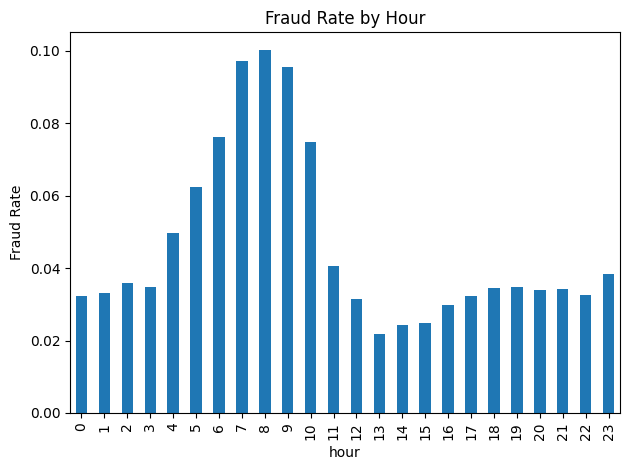

In [16]:
# ── Fraud rate by hour ─────────────────────────────────
fraud_by_hour = df.groupby("hour")["isFraud"].mean()
fraud_by_hour.plot(kind="bar", title="Fraud Rate by Hour")
plt.ylabel("Fraud Rate")
plt.tight_layout()
plt.show()

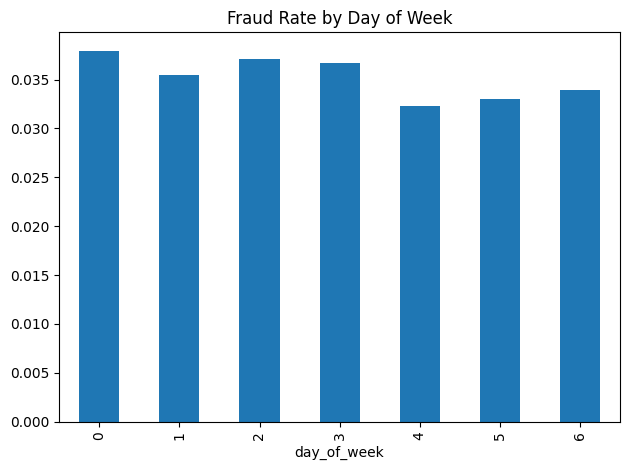

In [17]:
# ── Fraud rate by day of week ──────────────────────────
fraud_by_dow = df.groupby("day_of_week")["isFraud"].mean()
fraud_by_dow.plot(kind="bar", title="Fraud Rate by Day of Week")
plt.tight_layout()
plt.show()

## Amount Features - TransactionAmt

In [25]:
amt = df["TransactionAmt"]

# ── 1. Basic stats ──────────────────────────────────────────
print(f"Nulls    : {amt.isnull().sum()}")
print(f"Min      : {amt.min()}")
print(f"Max      : {amt.max()}")
print(f"Mean     : {amt.mean():.2f}")
print(f"Median   : {amt.median():.2f}")
print(f"Skew     : {amt.skew():.2f}") 

Nulls    : 0
Min      : 0.251
Max      : 31937.391
Mean     : 134.60
Median   : 68.95
Skew     : 17.64


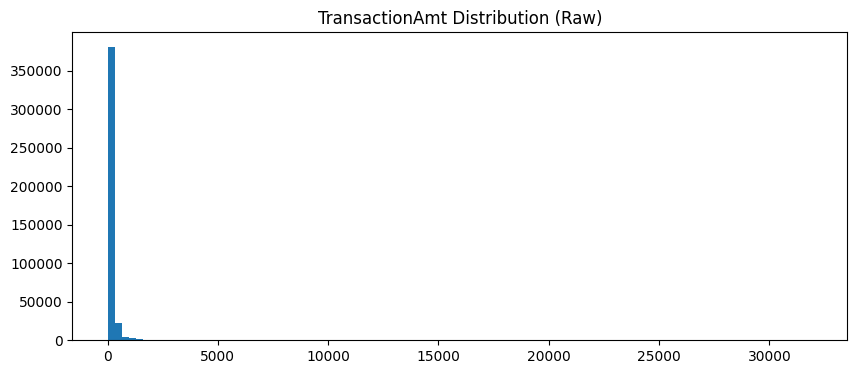

In [26]:
# ── 2. Distribution of raw amount ──────────────────────────
plt.figure(figsize=(10,4))
plt.hist(amt, bins=100)
plt.title("TransactionAmt Distribution (Raw)")
plt.show()

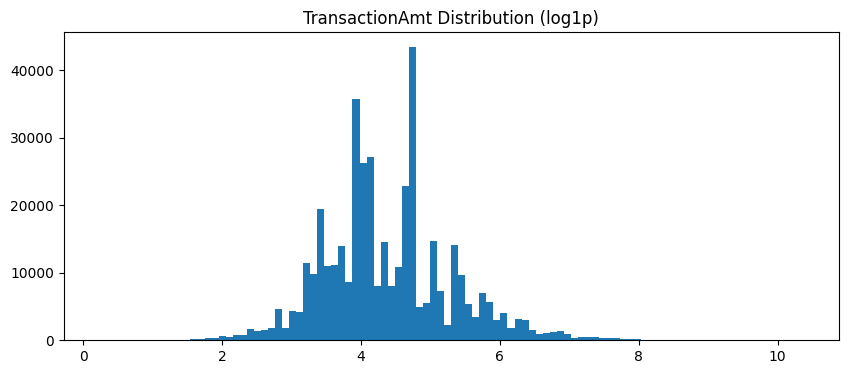

In [29]:
# ── 3. Distribution of log(amount) ─────────────────────────
plt.figure(figsize=(10,4))
plt.hist(np.log1p(amt), bins=100)
plt.title("TransactionAmt Distribution (log1p)")
plt.show()


In [30]:
# ── 4. Fraud rate by amount bucket ─────────────────────────
df["amt_bucket"] = pd.qcut(amt, q=10, duplicates="drop")
bucket_stats = df.groupby("amt_bucket")["isFraud"].agg(["mean", "count"])
print(bucket_stats)
# Looking for: do very low or very high amounts have higher fraud rate?

                        mean  count
amt_bucket                         
(0.25, 25.95]       0.055096  42399
(25.95, 35.95]      0.032957  42570
(35.95, 49.0]       0.032589  44678
(49.0, 57.95]       0.019187  42997
(57.95, 68.95]      0.028645  34177
(68.95, 100.0]      0.034690  52839
(100.0, 117.0]      0.019545  47684
(117.0, 160.5]      0.043484  24055
(160.5, 280.0]      0.040467  42553
(280.0, 31937.391]  0.050880  39426


/var/folders/g5/rmvc6_x949g6llq5g4spq06w0000gn/T/ipykernel_2764/3307270714.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bucket_stats = df.groupby("amt_bucket")["isFraud"].agg(["mean", "count"])


In [31]:
# ── 5. Cents analysis ──────────────────────────────────────
cents = (amt % 1).round(2)
print("\nTop 10 most common cent values:")
print(cents.value_counts().head(10))
# Looking for: are .00 and .99 cents more/less fraudulent?


Top 10 most common cent values:
TransactionAmt
0.00    217049
0.95    112125
0.50     15834
0.97      5586
0.99      4218
0.47      1593
0.36      1166
0.71       931
0.43       878
0.45       838
Name: count, dtype: int64


In [32]:
# ── 6. Fraud rate: round vs non-round amounts ───────────────
df["is_round"] = ((amt % 1) == 0).astype(int)
print("\nFraud rate by round amount:")
print(df.groupby("is_round")["isFraud"].mean())
# Looking for: round amounts ($50.00 vs $49.37) signal fraud?


Fraud rate by round amount:
is_round
0    0.034157
1    0.036086
Name: isFraud, dtype: float64


In [33]:
# Confirm the thresholds we picked
print("Fraud rate: amt < 26")
print(df[df["TransactionAmt"] < 26]["isFraud"].mean())

print("\nFraud rate: amt > 280")
print(df[df["TransactionAmt"] > 280]["isFraud"].mean())

print("\nFraud rate by cents_type")
df["cents_type"] = df["TransactionAmt"].apply(
    lambda x: 0 if round(x%1,2)==0.00
    else (1 if round(x%1,2)==0.95 else 2)
)
print(df.groupby("cents_type")["isFraud"].mean())

Fraud rate: amt < 26
0.055017781860147434

Fraud rate: amt > 280
0.050880129863541824

Fraud rate by cents_type
cents_type
0    0.036236
1    0.006760
2    0.070246
Name: isFraud, dtype: float64


### Null Information

In [34]:
# For each column with nulls, compare null rate in fraud vs legit
null_by_fraud = {}

for col in df.columns[df.isnull().any()]:
    fraud_null  = df[df["isFraud"]==1][col].isnull().mean()
    legit_null  = df[df["isFraud"]==0][col].isnull().mean()
    diff        = abs(fraud_null - legit_null)
    null_by_fraud[col] = {
        "fraud_null_rate": round(fraud_null, 3),
        "legit_null_rate": round(legit_null, 3),
        "diff":            round(diff, 3)
    }

result = pd.DataFrame(null_by_fraud).T
result = result.sort_values("diff", ascending=False)

print("Top 20 columns where null pattern differs between fraud/legit:")
print(result.head(20))

print(f"\nColumns with diff > 0.05: {(result['diff'] > 0.05).sum()}")
print(f"Columns with diff > 0.10: {(result['diff'] > 0.10).sum()}")

Top 20 columns where null pattern differs between fraud/legit:
               fraud_null_rate  legit_null_rate   diff
R_emaildomain            0.455            0.762  0.307
DeviceType               0.450            0.751  0.301
id_02                    0.450            0.751  0.301
id_29                    0.450            0.750  0.300
id_38                    0.450            0.750  0.300
id_37                    0.450            0.750  0.300
id_11                    0.450            0.750  0.300
id_36                    0.450            0.750  0.300
id_35                    0.450            0.750  0.300
id_31                    0.451            0.751  0.300
id_28                    0.450            0.750  0.300
id_15                    0.450            0.750  0.300
id_01                    0.447            0.745  0.297
id_05                    0.460            0.757  0.297
id_12                    0.447            0.745  0.297
id_06                    0.460            0.757  0.297
id

In [35]:
# Check: when id_01 is null, are the other id columns also null?
id_cols = [c for c in df.columns if c.startswith("id_")]
id_null_correlation = df[id_cols].isnull().corr()

# If they're all ~1.0 correlated in nullness → one flag is enough
print(id_null_correlation.round(2).to_string())

       id_01  id_02  id_05  id_06  id_11  id_12  id_13  id_15  id_16  id_17  id_19  id_20  id_28  id_29  id_31  id_35  id_36  id_37  id_38
id_01   1.00   0.98   0.97   0.97   0.99   1.00   0.91   0.99   0.93   0.98   0.98   0.98   0.99   0.99   0.98   0.99   0.99   0.99   0.99
id_02   0.98   1.00   0.98   0.98   1.00   0.98   0.89   1.00   0.95   0.99   0.99   0.99   1.00   1.00   1.00   1.00   1.00   1.00   1.00
id_05   0.97   0.98   1.00   1.00   0.98   0.97   0.87   0.98   0.93   0.99   0.99   0.99   0.98   0.98   0.98   0.98   0.98   0.98   0.98
id_06   0.97   0.98   1.00   1.00   0.98   0.97   0.87   0.98   0.93   0.99   0.99   0.99   0.98   0.98   0.98   0.98   0.98   0.98   0.98
id_11   0.99   1.00   0.98   0.98   1.00   0.99   0.89   1.00   0.95   0.99   0.99   0.99   1.00   1.00   1.00   1.00   1.00   1.00   1.00
id_12   1.00   0.98   0.97   0.97   0.99   1.00   0.91   0.99   0.93   0.98   0.98   0.98   0.99   0.99   0.98   0.99   0.99   0.99   0.99
id_13   0.91   0.89   0.87 

In [36]:
# ── Cell 1: id_13 and id_16 fraud signal ──────────────────
for col in ["id_13", "id_16"]:
    fraud_null = df[df["isFraud"]==1][col].isnull().mean()
    legit_null = df[df["isFraud"]==0][col].isnull().mean()
    print(f"{col}: fraud_null={fraud_null:.3f}  legit_null={legit_null:.3f}  diff={abs(fraud_null-legit_null):.3f}")

# ── Cell 2: Confirm one flag covers all id columns ─────────
# What % of rows where id_01 is null also have ALL other id cols null?
id_cols = [c for c in df.columns if c.startswith("id_")]
both_null = df[id_cols].isnull().all(axis=1)
id01_null = df["id_01"].isnull()
coverage  = (both_null == id01_null).mean()
print(f"\nid_01 null = ALL id cols null: {coverage:.3f}")
# If > 0.95 → one flag is enough ✅

# ── Cell 3: Confirm R_emaildomain and DeviceType are independent ──
for col in ["R_emaildomain", "DeviceType", "DeviceInfo"]:
    corr_with_id01 = df[[col, "id_01"]].isnull().corr().iloc[0,1]
    print(f"{col} null corr with id_01 null: {corr_with_id01:.3f}")
# If low correlation → they need their own flag
# If high correlation → they're part of same device data block

id_13: fraud_null=0.488  legit_null=0.779  diff=0.292
id_16: fraud_null=0.505  legit_null=0.770  diff=0.265

id_01 null = ALL id cols null: 1.000
R_emaildomain null corr with id_01 null: 0.892
DeviceType null corr with id_01 null: 0.984
DeviceInfo null corr with id_01 null: 0.885


## Aggregation Features

In [37]:
# How many unique values and cardinality of each groupby key
for col in ["card1", "card2", "addr1", "P_emaildomain"]:
    n_unique    = df[col].nunique()
    null_rate   = df[col].isnull().mean()
    fraud_rate  = df.groupby(col)["isFraud"].mean()
    print(f"\n{col}:")
    print(f"  Unique values : {n_unique}")
    print(f"  Null rate     : {null_rate:.3f}")
    print(f"  Fraud rate range: {fraud_rate.min():.3f} – {fraud_rate.max():.3f}")
    print(f"  Groups with >10% fraud: {(fraud_rate > 0.1).sum()}")


card1:
  Unique values : 12242
  Null rate     : 0.000
  Fraud rate range: 0.000 – 1.000
  Groups with >10% fraud: 700

card2:
  Unique values : 500
  Null rate     : 0.016
  Fraud rate range: 0.000 – 0.438
  Groups with >10% fraud: 33

addr1:
  Unique values : 318
  Null rate     : 0.115
  Fraud rate range: 0.000 – 0.667
  Groups with >10% fraud: 17

P_emaildomain:
  Unique values : 59
  Null rate     : 0.156
  Fraud rate range: 0.000 – 0.429
  Groups with >10% fraud: 4


In [38]:
# Cards that appear rarely vs often — which are more fraudulent?
card1_stats = df.groupby("card1").agg(
    txn_count  = ("isFraud", "count"),
    fraud_rate = ("isFraud", "mean"),
    mean_amt   = ("TransactionAmt", "mean"),
    std_amt    = ("TransactionAmt", "std")
).reset_index()

# Bin by transaction count
card1_stats["count_bin"] = pd.cut(
    card1_stats["txn_count"],
    bins=[0, 1, 5, 20, 100, 99999],
    labels=["1 txn", "2-5", "6-20", "21-100", "100+"]
)
print(card1_stats.groupby("count_bin")["fraud_rate"].mean())
# Looking for: do low-frequency cards have higher fraud rates?

count_bin
1 txn     0.034859
2-5       0.026311
6-20      0.024800
21-100    0.027675
100+      0.040388
Name: fraud_rate, dtype: float64


/var/folders/g5/rmvc6_x949g6llq5g4spq06w0000gn/T/ipykernel_2764/2942269651.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(card1_stats.groupby("count_bin")["fraud_rate"].mean())


In [39]:
# What does a card's historical behavior look like?
card1_agg = df.groupby("card1")["TransactionAmt"].agg(
    ["mean", "std", "count", "max", "min"]
).reset_index()
card1_agg.columns = ["card1", "mean_amt", "std_amt",
                     "txn_count", "max_amt", "min_amt"]

# Join back to train
train_temp = df.merge(card1_agg, on="card1", how="left")

# Does deviation from card's own mean signal fraud?
train_temp["amt_vs_card_mean"] = (
    train_temp["TransactionAmt"] - train_temp["mean_amt"]
)
print("Fraud rate by amt deviation from card mean:")
print(train_temp.groupby("isFraud")["amt_vs_card_mean"].describe())
# Looking for: do fraud txns deviate more from card's typical amount?

Fraud rate by amt deviation from card mean:
            count       mean         std          min        25%        50%  \
isFraud                                                                       
0        398840.0  -0.724872  225.241892 -2234.962500 -77.545737 -33.839079   
1         14538.0  19.886368  191.899981 -1086.016667 -51.899037 -13.585405   

               75%           max  
isFraud                           
0         9.712708  31674.812611  
1        33.606084   4056.655836  


In [40]:
# Which email domains are riskier?
email_stats = df.groupby("P_emaildomain").agg(
    txn_count  = ("isFraud", "count"),
    fraud_rate = ("isFraud", "mean")
).sort_values("fraud_rate", ascending=False)

print("Top 15 most fraudulent email domains (min 100 txns):")
print(email_stats[email_stats["txn_count"] > 100].head(15))

print("\nBottom 10 safest email domains (min 100 txns):")
print(email_stats[email_stats["txn_count"] > 100].tail(10))
# Looking for: big difference between risky vs safe domains?

Top 15 most fraudulent email domains (min 100 txns):
                 txn_count  fraud_rate
P_emaildomain                         
mail.com               398    0.198492
aim.com                239    0.167364
outlook.es             340    0.132353
outlook.com           3550    0.089014
hotmail.es             201    0.079602
hotmail.com          32817    0.053448
gmail.com           159214    0.044041
frontiernet.net        131    0.038168
live.com              2189    0.035633
icloud.com            4319    0.031026
live.com.mx            557    0.028725
embarqmail.com         178    0.028090
mac.com                336    0.026786
yahoo.com            70404    0.023649
anonymous.com        26745    0.023593

Bottom 10 safest email domains (min 100 txns):
                 txn_count  fraud_rate
P_emaildomain                         
netzero.com            160         0.0
centurylink.net        126         0.0
windstream.net         191         0.0
web.de                 146         0.0
ne

In [41]:
# card1 + addr1 together = closest thing to a unique customer
df["uid"] = df["card1"].astype(str) + "_" + df["addr1"].astype(str)

uid_stats = df.groupby("uid").agg(
    txn_count  = ("isFraud", "count"),
    fraud_rate = ("isFraud", "mean"),
    mean_amt   = ("TransactionAmt", "mean")
).reset_index()

print(f"Unique card1+addr1 combos : {len(uid_stats):,}")
print(f"Combos with >1 transaction: {(uid_stats['txn_count'] > 1).sum():,}")
print(f"\nFraud rate distribution across uids:")
print(uid_stats["fraud_rate"].describe())

# Do uids with more transactions have lower fraud rates?
uid_stats["count_bin"] = pd.cut(
    uid_stats["txn_count"],
    bins=[0,1,3,10,50,99999],
    labels=["1","2-3","4-10","11-50","50+"]
)
print("\nFraud rate by uid transaction count:")
print(uid_stats.groupby("count_bin")["fraud_rate"].mean())
# Looking for: established customers (many txns) = lower fraud?

Unique card1+addr1 combos : 34,755
Combos with >1 transaction: 20,525

Fraud rate distribution across uids:
count    34755.000000
mean         0.029416
std          0.147470
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: fraud_rate, dtype: float64

Fraud rate by uid transaction count:
count_bin
1        0.030288
2-3      0.030617
4-10     0.026367
11-50    0.027488
50+      0.035411
Name: fraud_rate, dtype: float64


/var/folders/g5/rmvc6_x949g6llq5g4spq06w0000gn/T/ipykernel_2764/2700938591.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(uid_stats.groupby("count_bin")["fraud_rate"].mean())


In [42]:
# Confirm card1_std_amt signal
train_temp["card1_std_amt"] = df.groupby("card1")["TransactionAmt"].transform("std")

print("card1_std_amt by fraud label:")
print(df.assign(
    card1_std = df.groupby("card1")["TransactionAmt"].transform("std")
).groupby("isFraud")["card1_std"].describe())

card1_std_amt by fraud label:
            count        mean         std  min        25%         50%  \
isFraud                                                                 
0        395656.0  184.796332  131.903910  0.0  98.830697  172.292210   
1         14423.0  165.758198  148.241754  0.0  41.379540  142.814964   

                75%          max  
isFraud                           
0        241.805875  2506.658184  
1        251.385761  1199.899664  
